In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("netflix_titles.csv")

print("Dataset Shape:", df.shape)
print(df.head())

ERROR! Session/line number was not unique in database. History logging moved to new session 7
Dataset Shape: (8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021  

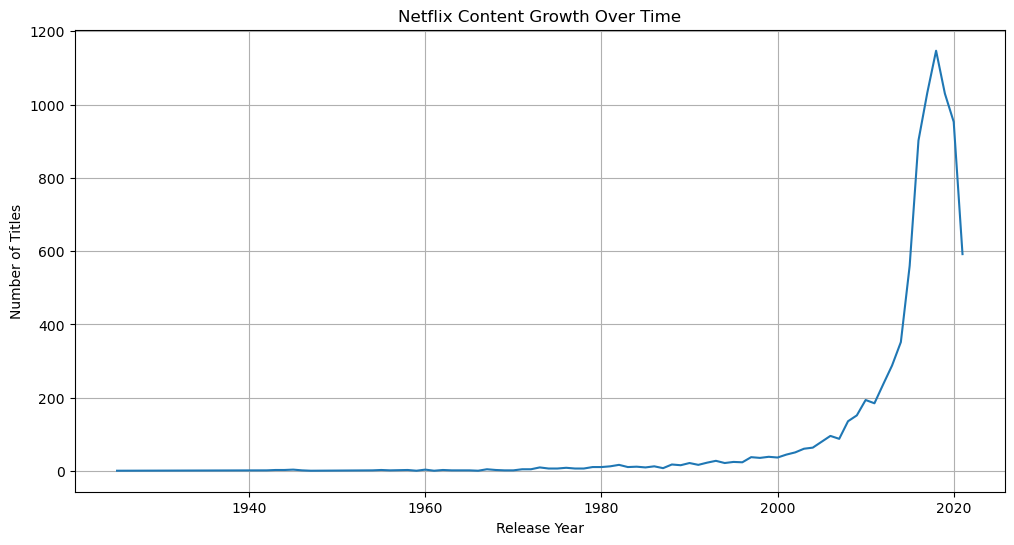

In [8]:
yearly_content = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
yearly_content.plot(kind='line')
plt.title('Netflix Content Growth Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

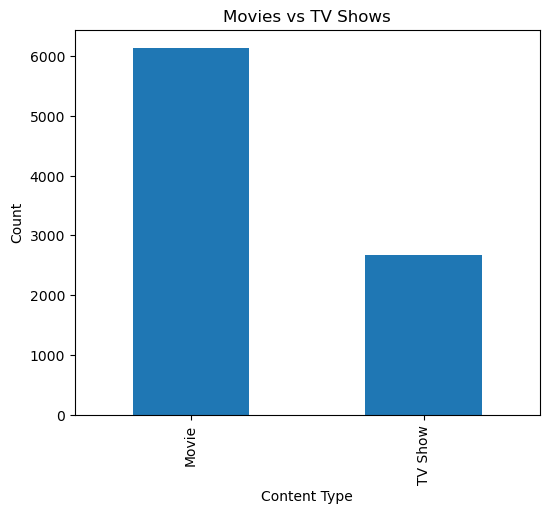

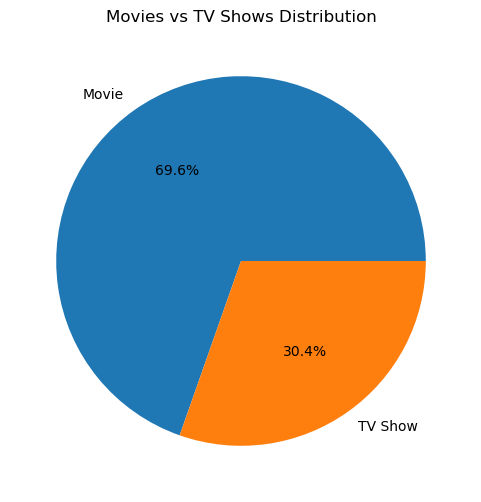

In [9]:
content_type = df['type'].value_counts()

plt.figure(figsize=(6,5))
content_type.plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
content_type.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Movies vs TV Shows Distribution')
plt.show()

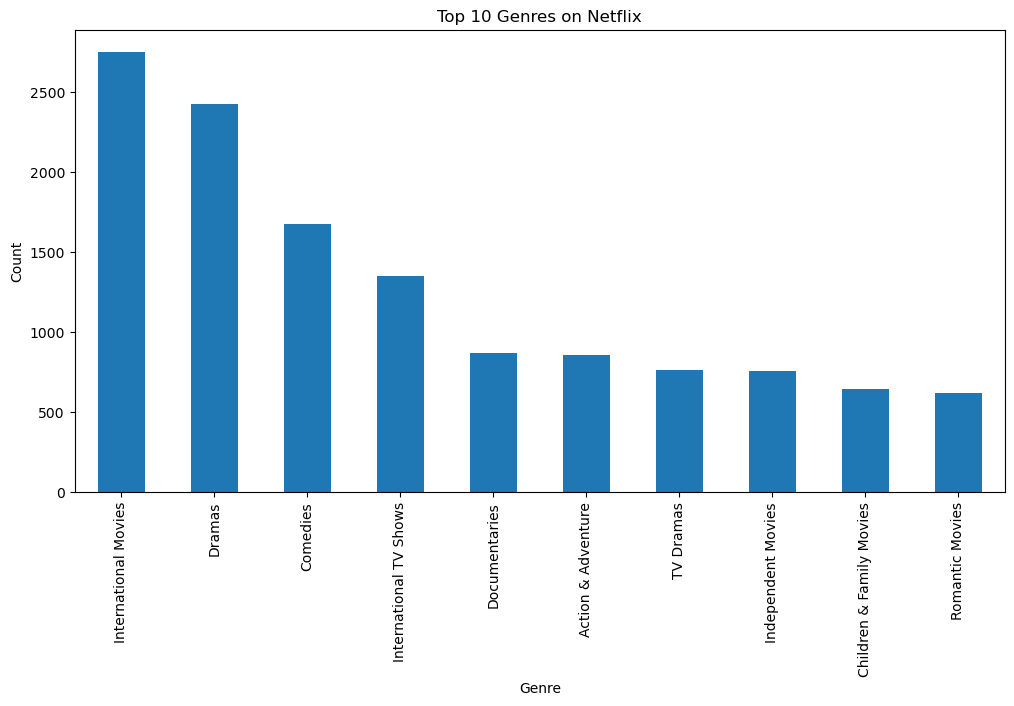

In [10]:
genres = df['listed_in'].str.split(', ')

all_genres = []

for genre_list in genres:
    all_genres.extend(genre_list)

genre_counts = pd.Series(all_genres).value_counts()

plt.figure(figsize=(12,6))
genre_counts.head(10).plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()


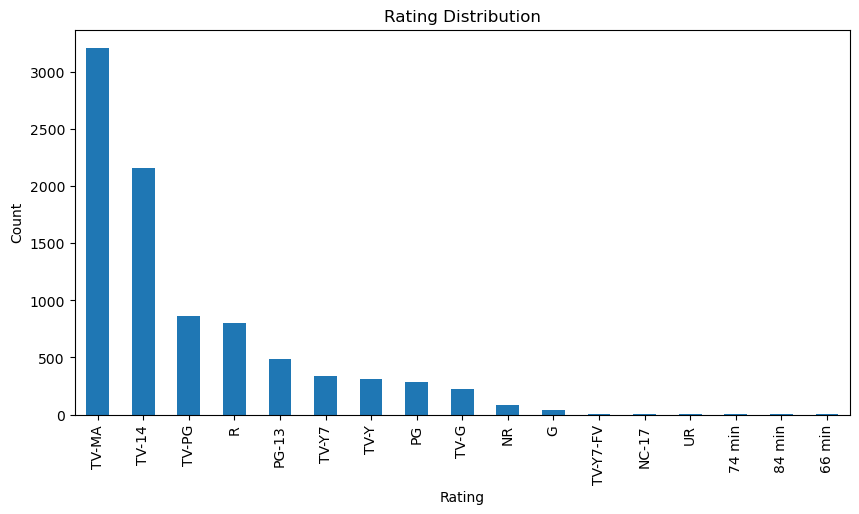

In [11]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10,5))
rating_counts.plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

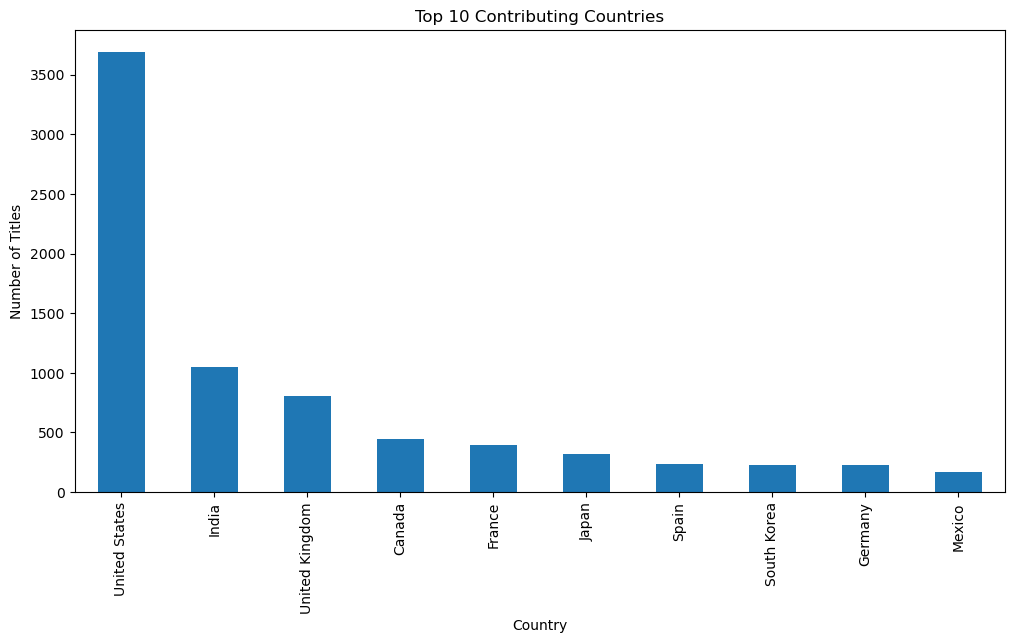

In [12]:
country_data = df['country'].dropna()

countries = []

for item in country_data:
    countries.extend([c.strip() for c in item.split(',')])

country_counts = pd.Series(countries).value_counts()

plt.figure(figsize=(12,6))
country_counts.head(10).plot(kind='bar')
plt.title('Top 10 Contributing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()


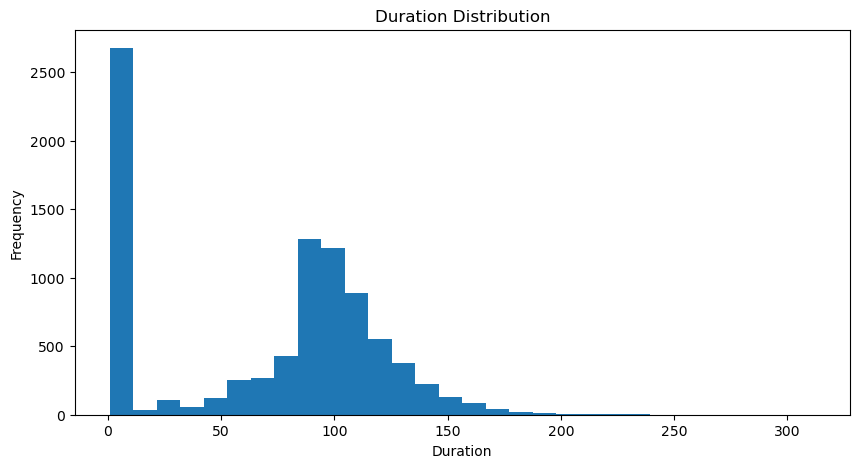

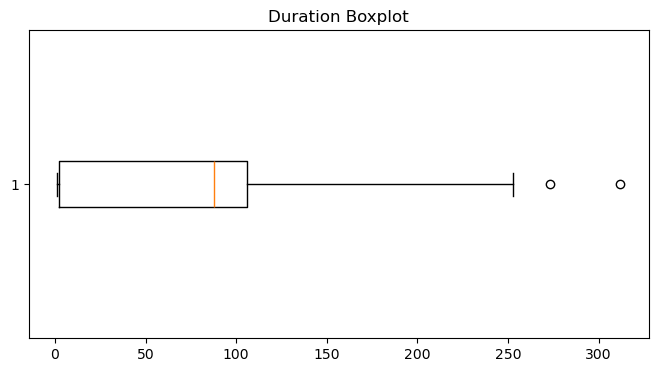

In [13]:
# Extract numeric duration
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,5))
plt.hist(df['duration_num'].dropna(), bins=30)
plt.title('Duration Distribution')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(df['duration_num'].dropna(), vert=False)
plt.title('Duration Boxplot')
plt.show()

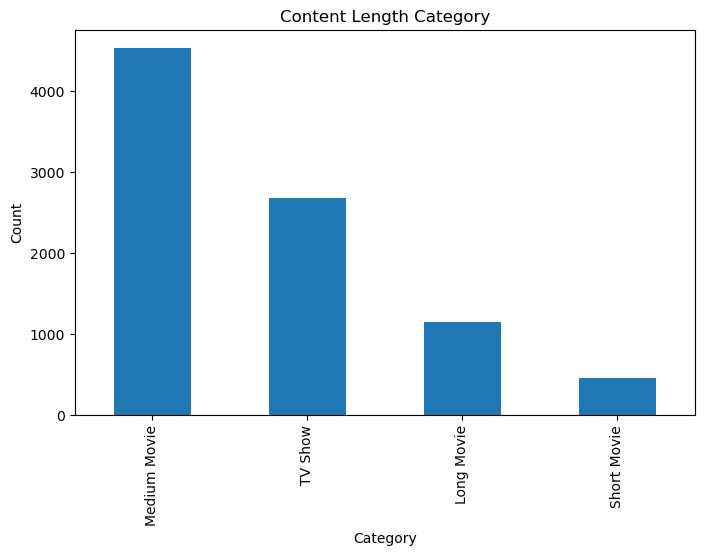

In [40]:
def categorize_duration(x):
    if pd.isna(x):
        return np.nan
    elif x < 60:
        return 'Short'
    elif x <= 120:
        return 'Medium'
    else:
        return 'Long'

df['content_length_category'] = df['duration_num'].apply(categorize_duration)
# Visualization
plt.figure(figsize=(8,5))
df['Content_Length_Category'].value_counts().plot(kind='bar')
plt.title("Content Length Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

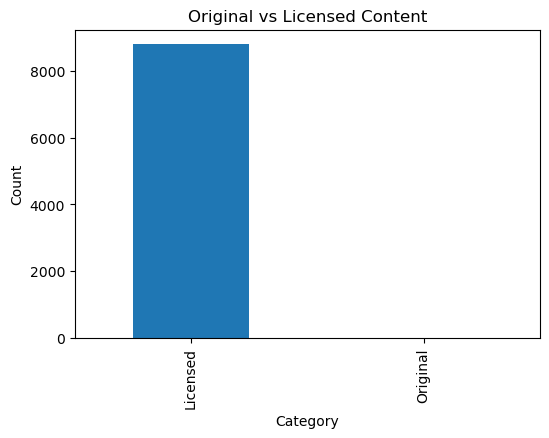

In [41]:
CURRENT_YEAR = 2026
df['content_age'] = CURRENT_YEAR - df['release_year']
# Visualization
plt.figure(figsize=(6,4))
df['Original_vs_Licensed'].value_counts().plot(kind='bar')
plt.title("Original vs Licensed Content")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

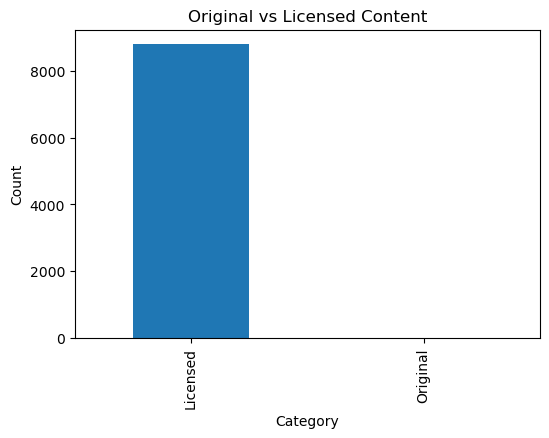

In [48]:
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'
# Visualization
plt.figure(figsize=(6,4))
df['Original_vs_Licensed'].value_counts().plot(kind='bar')
plt.title("Original vs Licensed Content")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


In [49]:
df['genre_count'] = df['listed_in'].apply(
    lambda x: len(str(x).split(','))
)

# ==========================================
# CHECK NEW FEATURES
# ==========================================

print("\nNew Features Created:")
print(df[['content_length_category',
          'content_age',
          'decade',
          'genre_count']].head())

# ==========================================
# SAVE FEATURE ENGINEERED DATASET
# ==========================================

df.to_csv("netflix_featured.csv", index=False)

print("\nFeature Engineered Dataset Saved Successfully!")
print("File Name: netflix_featured.csv")

# ==========================================
# SUMMARY STATISTICS
# ==========================================

print("\nTop 10 Genres:")
print(genre_counts.head(10))

print("\nTop 10 Countries:")
print(country_counts.head(10))

print("\nContent Type Distribution:")
print(content_type)



New Features Created:
  content_length_category  content_age decade  genre_count
0                  Medium            6  2020s            1
1                   Short            5  2020s            3
2                   Short            5  2020s            3
3                   Short            5  2020s            2
4                   Short            5  2020s            3

Feature Engineered Dataset Saved Successfully!
File Name: netflix_featured.csv

Top 10 Genres:
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Top 10 Countries:
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain         